# Remaining Useful Life (RUL) Prediction - FD001

This notebook walks through predicting the Remaining Useful Life of turbofan engines using the NASA C-MAPSS FD001 dataset.

**Dataset**: 100 engines, each running until failure, with 21 sensor readings and 3 operational settings per cycle.

## 1. Import Libraries

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 2. Load Data

The raw text file has no column headers. We define them manually:
- Column 1: engine unit number
- Column 2: time in cycles
- Columns 3-5: 3 operational settings
- Columns 6-26: 21 sensor measurements

In [32]:
# Define column names since the raw data has no headers
columns = ['unit', 'cycle',
           'setting_1', 'setting_2', 'setting_3'] + \
          [f'sensor_{i}' for i in range(1, 22)]

# Read the space-separated text file
train_df = pd.read_csv('../CMaps/train_FD001.txt',
                        sep='\\s+', header=None, names=columns)

print(f'Shape: {train_df.shape}')
print(f'Number of engines: {train_df["unit"].nunique()}')
train_df.head()

Shape: (20631, 26)
Number of engines: 100


,unit,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 3. Exploratory Data Analysis

Engine lifecycle statistics:
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: max_cycle, dtype: float64


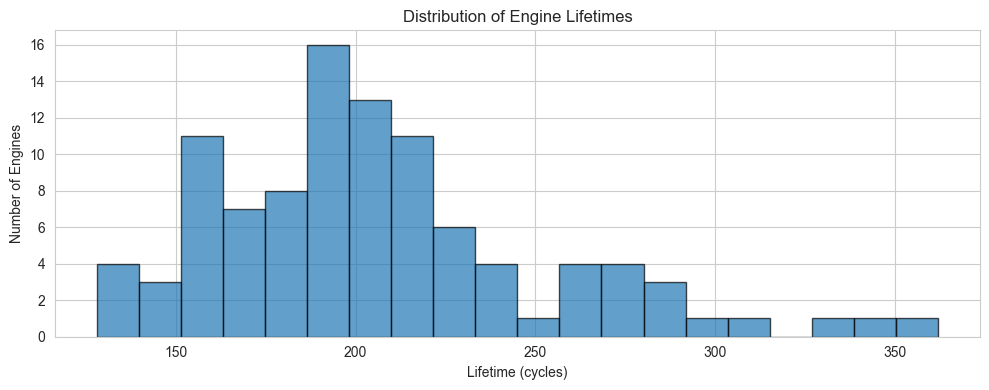

In [33]:
# Check the lifecycle length of each engine
lifecycle = train_df.groupby('unit')['cycle'].max().reset_index()
lifecycle.columns = ['unit', 'max_cycle']

print(f'Engine lifecycle statistics:')
print(lifecycle['max_cycle'].describe())

# Plot distribution of engine lifetimes
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lifecycle['max_cycle'], bins=20, edgecolor='black', alpha=0.7)
ax.set_xlabel('Lifetime (cycles)')
ax.set_ylabel('Number of Engines')
ax.set_title('Distribution of Engine Lifetimes')
plt.tight_layout()
plt.show()

In [34]:
# Summary statistics to identify constant or near-constant sensors
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
unit,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200


## 4. Construct RUL Labels

In the training set, each engine runs until failure. The last recorded cycle IS the failure point.

So for each row: **RUL = max_cycle_of_that_engine - current_cycle**

For example, if engine 1 has 192 cycles total, then at cycle 1 its RUL = 191, at cycle 100 its RUL = 92, and at cycle 192 its RUL = 0.

In [35]:
# For each engine, find the maximum cycle (= failure point)
max_cycles = train_df.groupby('unit')['cycle'].max()

# Merge back and compute RUL
train_df['RUL'] = train_df.apply(
    lambda row: max_cycles[row['unit']] - row['cycle'], axis=1
)

print('RUL column added. Example for engine 1:')
train_df[train_df['unit'] == 1][['unit', 'cycle', 'RUL']].tail(10)

RUL column added. Example for engine 1:


,unit,cycle,RUL
182,1,183,9.0
183,1,184,8.0
184,1,185,7.0
185,1,186,6.0
186,1,187,5.0
187,1,188,4.0
188,1,189,3.0
189,1,190,2.0
190,1,191,1.0
191,1,192,0.0


## 5. Visualization

Let's look at how sensor readings change over the engine's lifecycle. A clear degradation trend means the sensor is useful for prediction.

Top 6 sensors by |correlation| with RUL: ['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_15', 'sensor_21']
sensor_11   -0.696228
sensor_4    -0.678948
sensor_15   -0.642667
sensor_21    0.635662
sensor_7     0.657223
sensor_12    0.671983
Name: RUL, dtype: float64


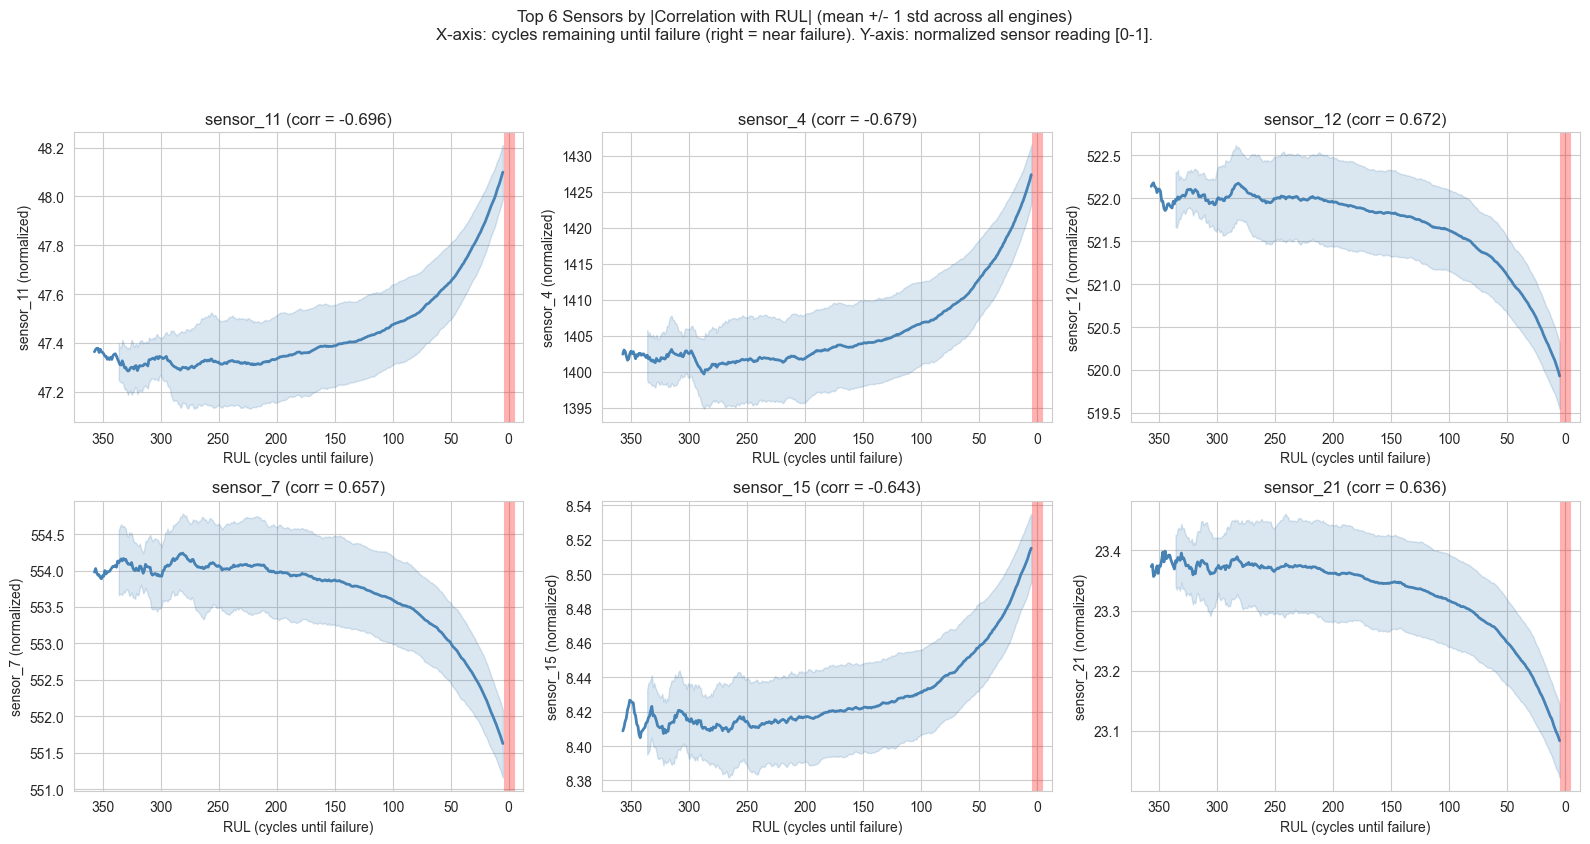

Interpretation:
- Read each plot from LEFT (healthy) to RIGHT (near failure).
  sensor_11 (corr=-0.696): rises as engine approaches failure.
  sensor_4 (corr=-0.679): rises as engine approaches failure.
  sensor_12 (corr=+0.672): drops as engine approaches failure.
  sensor_7 (corr=+0.657): drops as engine approaches failure.
  sensor_15 (corr=-0.643): rises as engine approaches failure.
  sensor_21 (corr=+0.636): drops as engine approaches failure.


In [36]:
# Select the top 6 sensors by absolute correlation with RUL.
# Higher |correlation| means the sensor shows a clearer degradation trend,
# making it more useful for predicting RUL.

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
corr_with_rul = train_df[sensor_cols + ['RUL']].corr()['RUL'].drop('RUL')
top_sensors = corr_with_rul.abs().sort_values(ascending=False).head(6).index.tolist()
print(f'Top 6 sensors by |correlation| with RUL: {top_sensors}')
print(corr_with_rul[top_sensors].sort_values())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, sensor in enumerate(top_sensors):
    ax = axes[idx]
    # Average across all engines at each RUL value, smoothed with rolling window
    grouped = train_df.groupby('RUL')[sensor].agg(['mean', 'std'])
    rul_vals = grouped.index.values
    mean_smooth = grouped['mean'].rolling(window=10, center=True).mean()
    std_smooth = grouped['std'].rolling(window=10, center=True).mean()

    ax.fill_between(rul_vals, mean_smooth - std_smooth, mean_smooth + std_smooth,
                    alpha=0.2, color='steelblue')
    ax.plot(rul_vals, mean_smooth, color='steelblue', linewidth=2)
    ax.set_xlabel('RUL (cycles until failure)')
    ax.set_ylabel(f'{sensor} (normalized)')
    corr_val = corr_with_rul[sensor]
    ax.set_title(f'{sensor} (corr = {corr_val:.3f})')
    ax.invert_xaxis()
    # Mark the failure point
    ax.axvline(x=0, color='red', linestyle='-', alpha=0.3, linewidth=8)

plt.suptitle('Top 6 Sensors by |Correlation with RUL| (mean +/- 1 std across all engines)\n'
             'X-axis: cycles remaining until failure (right = near failure). '
             'Y-axis: normalized sensor reading [0-1].',
             y=1.05, fontsize=12)
plt.tight_layout()
plt.show()

# Interpretation
print('Interpretation:')
print('- Read each plot from LEFT (healthy) to RIGHT (near failure).')
for sensor in top_sensors:
    corr_val = corr_with_rul[sensor]
    if corr_val < 0:
        print(f'  {sensor} (corr={corr_val:+.3f}): rises as engine approaches failure.')
    else:
        print(f'  {sensor} (corr={corr_val:+.3f}): drops as engine approaches failure.')

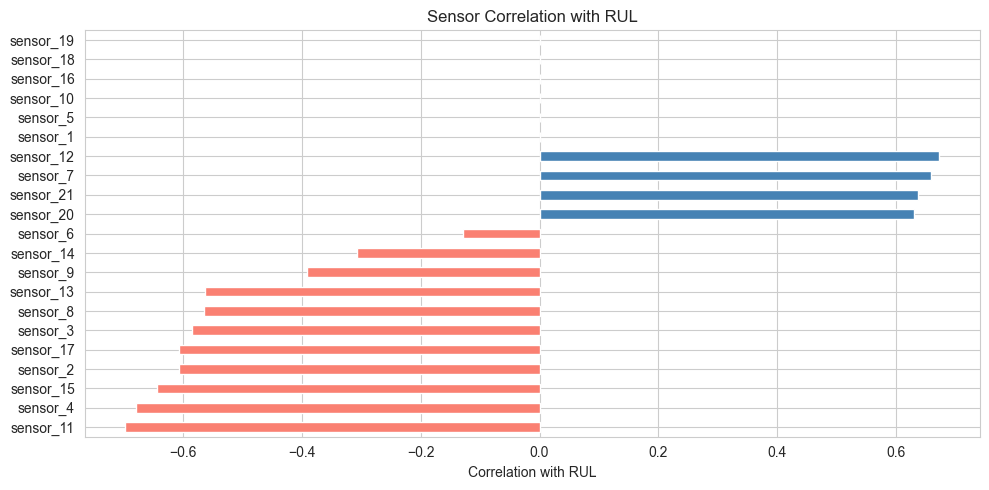

In [37]:
# Correlation heatmap: which sensors correlate most with RUL?
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
corr_with_rul = train_df[sensor_cols + ['RUL']].corr()['RUL'].drop('RUL').sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
corr_with_rul.plot(kind='barh', ax=ax, color=['salmon' if v < 0 else 'steelblue' for v in corr_with_rul])
ax.set_xlabel('Correlation with RUL')
ax.set_title('Sensor Correlation with RUL')
plt.tight_layout()
plt.show()

## 6. Data Preprocessing

Three key steps:

1. **Remove constant columns** - Sensors with zero variance carry no information
2. **Clip RUL at 125** - In early operation, degradation is invisible. A model can't distinguish RUL=200 from RUL=300. Capping at 125 is a standard technique that helps the model focus on the degradation region.
3. **Normalize features** - Different sensors have very different scales (e.g. temperature in hundreds vs pressure ratios near 1). Normalization puts them on the same scale so no single feature dominates.

In [38]:
# Step 1: Identify and drop constant (zero-variance) columns
feature_cols = ['setting_1', 'setting_2', 'setting_3'] + sensor_cols
variances = train_df[feature_cols].var()
constant_cols = variances[variances < 1e-6].index.tolist()
print(f'Constant columns (will be dropped): {constant_cols}')

feature_cols = [c for c in feature_cols if c not in constant_cols]
print(f'\nRemaining features ({len(feature_cols)}): {feature_cols}')

Constant columns (will be dropped): ['setting_2', 'setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

Remaining features (16): ['setting_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


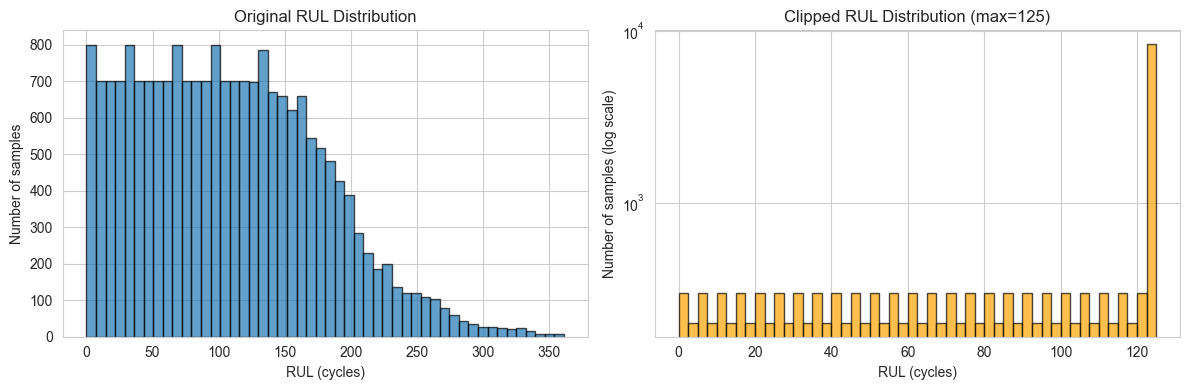

8131 out of 20631 samples (39.4%) had RUL >= 125 and were clipped to 125.


In [39]:
# Step 2: Clip RUL at 125
RUL_CLIP = 125
train_df['RUL_clipped'] = train_df['RUL'].clip(upper=RUL_CLIP)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_df['RUL'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Original RUL Distribution')
axes[0].set_xlabel('RUL (cycles)')
axes[0].set_ylabel('Number of samples')

axes[1].hist(train_df['RUL_clipped'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title(f'Clipped RUL Distribution (max={RUL_CLIP})')
axes[1].set_xlabel('RUL (cycles)')
axes[1].set_ylabel('Number of samples (log scale)')
axes[1].set_yscale('log')  # Log scale so the 125 spike doesn't crush everything else

plt.tight_layout()
plt.show()

clipped_count = (train_df['RUL'] >= RUL_CLIP).sum()
total_count = len(train_df)
print(f'{clipped_count} out of {total_count} samples ({clipped_count/total_count:.1%}) '
      f'had RUL >= {RUL_CLIP} and were clipped to {RUL_CLIP}.')

In [40]:
# Step 3: Normalize features to [0, 1]
# IMPORTANT: fit the scaler on a COPY of the raw data so re-running this cell
# doesn't corrupt the scaler (fitting on already-normalized data would break it).
raw_features = train_df[feature_cols].copy()
scaler = MinMaxScaler()
scaler.fit(raw_features)
train_df[feature_cols] = scaler.transform(raw_features)

print('Features normalized to [0, 1].')
train_df[feature_cols].describe().loc[['min', 'max']]

Features normalized to [0, 1].


,setting_1,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 7. Train-Validation Split & Model Training

In [41]:
# Prepare features (X) and target (y)
X = train_df[feature_cols].values
y = train_df['RUL_clipped'].values

# 80/20 split, with a fixed random seed for reproducibility
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training set: {X_train.shape[0]} samples')
print(f'Validation set: {X_val.shape[0]} samples')

Training set: 16504 samples
Validation set: 4127 samples


In [42]:
def evaluate_model(name, model, X_tr, y_tr, X_v, y_v):
    """Train a model and print evaluation metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_v)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    mae = mean_absolute_error(y_v, y_pred)
    r2 = r2_score(y_v, y_pred)
    print(f'{name:20s} | RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.3f}')
    return {'name': name, 'model': model, 'rmse': rmse, 'mae': mae, 'r2': r2}

print(f'{"Model":20s} | {"RMSE":>6s} | {"MAE":>6s} | {"R2":>6s}')
print('-' * 55)

results = []
results.append(evaluate_model('Linear Regression',
    LinearRegression(), X_train, y_train, X_val, y_val))
results.append(evaluate_model('Random Forest',
    RandomForestRegressor(n_estimators=100, random_state=42),
    X_train, y_train, X_val, y_val))
results.append(evaluate_model('XGBoost',
    XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    X_train, y_train, X_val, y_val))

Model                |   RMSE |    MAE |     R2
-------------------------------------------------------
Linear Regression    | RMSE: 21.68 | MAE: 17.61 | R2: 0.723
Random Forest        | RMSE: 18.77 | MAE: 13.58 | R2: 0.792
XGBoost              | RMSE: 18.72 | MAE: 13.31 | R2: 0.793


Best model: XGBoost


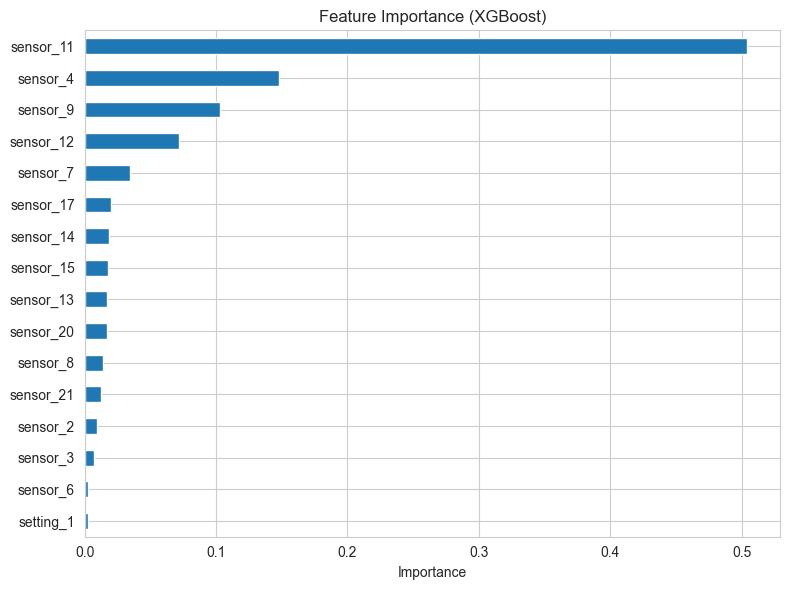

In [43]:
# Feature importance from the best tree model
best_result = min(results, key=lambda x: x['rmse'])
best_model = best_result['model']
print(f'Best model: {best_result["name"]}')

if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=feature_cols)
    importance = importance.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    importance.plot(kind='barh', ax=ax)
    ax.set_title(f'Feature Importance ({best_result["name"]})')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

## 8. Test Set Evaluation

In [44]:
# Load test data and true RUL values
test_df = pd.read_csv('../CMaps/test_FD001.txt',
                       sep='\\s+', header=None, names=columns)
rul_true = pd.read_csv('../CMaps/RUL_FD001.txt',
                        header=None, names=['RUL'])

# For the test set, we only predict RUL at the LAST cycle of each engine
test_last = test_df.groupby('unit').last().reset_index()

# Apply the same preprocessing: drop constant columns, normalize with SAME scaler
test_last[feature_cols] = scaler.transform(test_last[feature_cols])

# Clip true RUL to the same threshold used in training
y_test_true = rul_true['RUL'].clip(upper=RUL_CLIP).values

# Predict
X_test = test_last[feature_cols].values
y_test_pred = best_model.predict(X_test)

# Debug: check what predictions look like
print('--- Diagnostic ---')
print(f'Predictions  - min: {y_test_pred.min():.1f}, max: {y_test_pred.max():.1f}, mean: {y_test_pred.mean():.1f}')
print(f'True values  - min: {y_test_true.min():.1f}, max: {y_test_true.max():.1f}, mean: {y_test_true.mean():.1f}')
print(f'\nFirst 10 comparisons (true -> predicted):')
for i in range(10):
    print(f'  Engine {i+1}: true={y_test_true[i]:.0f}, pred={y_test_pred[i]:.1f}, error={abs(y_test_true[i]-y_test_pred[i]):.1f}')

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
mae = mean_absolute_error(y_test_true, y_test_pred)
r2 = r2_score(y_test_true, y_test_pred)
print(f'\nTest Set Results ({best_result["name"]})')
print(f'RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.3f}')

--- Diagnostic ---
Predictions  - min: 5.9, max: 124.6, mean: 77.9
True values  - min: 7.0, max: 125.0, mean: 74.5

First 10 comparisons (true -> predicted):
  Engine 1: true=112, pred=121.0, error=9.0
  Engine 2: true=98, pred=122.1, error=24.1
  Engine 3: true=69, pred=64.5, error=4.5
  Engine 4: true=82, pred=89.3, error=7.3
  Engine 5: true=91, pred=103.2, error=12.2
  Engine 6: true=93, pred=97.1, error=4.1
  Engine 7: true=91, pred=97.3, error=6.3
  Engine 8: true=95, pred=105.6, error=10.6
  Engine 9: true=111, pred=101.6, error=9.4
  Engine 10: true=96, pred=105.2, error=9.2

Test Set Results (XGBoost)
RMSE: 16.73 | MAE: 11.83 | R2: 0.826


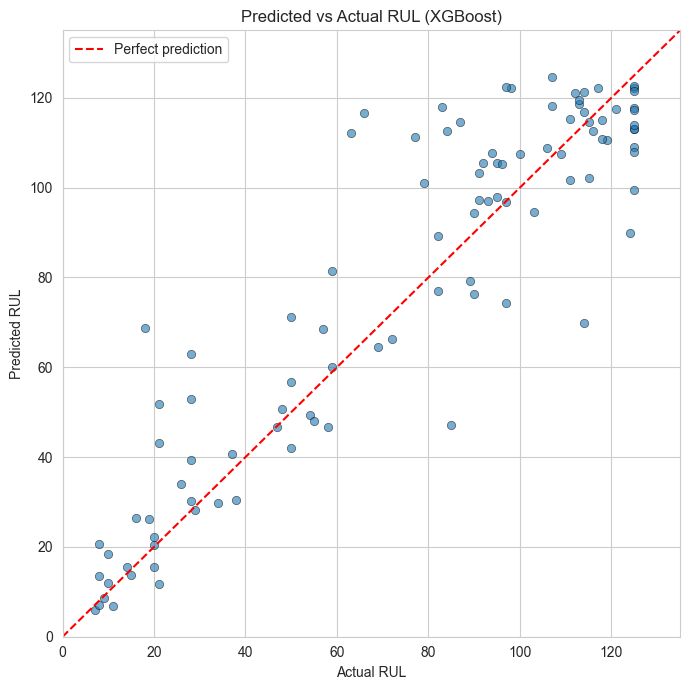

In [45]:
# Predicted vs Actual scatter plot
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test_true, y_test_pred, alpha=0.6, edgecolors='black', linewidths=0.5)
max_val = max(y_test_true.max(), y_test_pred.max()) + 10
ax.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
ax.set_xlabel('Actual RUL')
ax.set_ylabel('Predicted RUL')
ax.set_title(f'Predicted vs Actual RUL ({best_result["name"]})')
ax.legend()
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
plt.tight_layout()
plt.show()